In [67]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load in some of the SciKit Learn Preprocessing and Dimensionality Reduction Tools
from sklearn.preprocessing import Binarizer, StandardScaler
from sklearn.decomposition import PCA

# Let's load in some key features from SciKit Learn where we can split the datasets up
# do the grid search, and construct a ML Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

# Let's load in some potential models (Decision Tree and SVC)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.svm import SVC

# Let's load in some metrics packages to assess the quality of our models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Machine Learning Classification: A Complete Tutorial

## Introduction

This notebook provides a comprehensive guide to building machine learning classification models in Python using scikit-learn. Classification is a **supervised learning** task where we predict categorical outcomes based on input features. For example, in meteorology, we might classify supercells as "tornado-producing" or "non-tornado-producing" based on atmospheric measurements.

### Key Concepts

- **Training Data**: Used to fit the model and learn patterns
- **Testing Data**: Held out to evaluate model performance (never use for training!)
- **Hyperparameters**: Model settings that we choose (not learned from data)
- **Cross-Validation**: Technique to robustly estimate model performance
- **Overfitting**: When a model memorizes training data but fails on new data

---

# Part 1: Basics of Building a Classification Model

## Step 1: Load and Explore Your Data

The first step in any machine learning project is to load and understand your dataset. We're using SARS (Severe and Rare Supercells) data—atmospheric observations of supercell thunderstorms. Our goal is to build a classifier that predicts whether a supercell will produce a tornado.

**Why this matters**: Understanding your data's shape, variable types, and distributions is essential before building models.

In [68]:
data = pd.read_csv("/share/data/ESCI446/SARS/sars_supercell.txt",\
                   delimiter='\t',
                   on_bad_lines='skip')

In [69]:
data

,FILENAME,CAT,MLMIXR,ML CAPE,ML CIN,MLCL(MAGL),0-1SRH,0-6KT,STPC,500 T (C),500DIR,7-5 LR,0-3(KT),0-9(KT),0-3 KM SRH (M2/S2)
0,00042320.TXK,2,12.9,1702,-1,657,134,61.7,2.3,-14.0,250,6.5,32.8,76.6,166
1,00042001.PPF,2,13.5,2614,-50,1216,227,59.9,4.7,-12.9,234,7.5,39.7,73.5,244
2,00032900.FTW,2,13.1,2058,-42,1069,83,49.7,1.3,-15.2,245,8.0,21.9,87.1,126
3,00032304.SJT,2,11.9,1680,-119,896,119,61.1,1.1,-15.5,212,9.1,38.4,66.9,217
4,00031622.ATT,2,9.4,1019,-7,1566,12,45.8,0.0,-17.5,249,8.0,34.4,53.7,159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,99082022.DIK,0,11.7,1445,-10,1669,21,33.6,0.1,-7.8,298,6.3,17.8,36.0,58
838,99081922.MLS,0,7.1,393,-105,3278,19,33.8,0.0,-10.0,244,8.6,22.0,37.3,120
839,99081800.RRT,0,11.4,1524,-26,847,90,49.2,1.1,-17.7,268,7.3,32.2,62.0,126
840,99081400.ALB,0,16.8,1843,-4,701,196,38.5,2.3,-6.3,249,5.8,29.9,48.4,252


## Step 2: Exploratory Data Analysis (EDA)

Before building a model, we should understand our data through visualization and statistical analysis. This includes:

- **Distributions**: Are variables normally distributed? Are there outliers?
- **Missing Values**: How much data is missing? Do patterns exist in the missingness?
- **Correlations**: Which features are related to our target variable?
- **Class Balance**: Do we have roughly equal numbers of each class (tornado vs. no tornado)?

We're skipping detailed EDA here since we've covered it extensively in earlier notebooks. However, EDA is **critical** in real projects. A model is only as good as the data it's built from!

## Step 3: Prepare Features and Target Variable

Machine learning models require two components:

- **Features (X)**: The input variables used to make predictions (atmospheric measurements)
- **Target (y)**: The outcome we want to predict (tornado or no tornado)

In this step, we:
1. Remove unnecessary columns (filename, non-feature metadata)
2. Convert the categorical target into binary values (0 = no tornado, 1 = tornado)
3. Use **Binarizer** to apply a threshold—values at or above the threshold become 1, below become 0

This preparation ensures our model receives properly formatted data.

In [70]:
x_values = data.drop(columns=['FILENAME','CAT'], axis=1) # Our Predictors (X)

## Create a binary label for cases when there was no tornado and when there was a tornado.
bin_transform = Binarizer(threshold=0.5) # Create a Binarizer object that will generate a 0 or 1 based upon the threshold.
y_values = bin_transform.transform(data['CAT'].to_numpy().reshape(-1,1)) # Convert the CAT data to 0s (NoTor) and 1s (Tor)
y_values = pd.DataFrame(y_values, columns=["TorCategory"]) # Put the Y values in a Dataframe and label the column "TorCategory"

## Step 4: Train-Test Split

One of the most important principles in machine learning is **never to train and test on the same data**. This would be like studying with the exact exam questions—you wouldn't know if you truly learned the material or just memorized answers.

We split our data into:
- **Training Set (80%)**: Used to fit the model and learn patterns
- **Testing Set (20%)**: Held completely separate, used only at the end to evaluate final performance

**Critical Rule**: Don't look at the test set during model development! Any decision influenced by test performance creates **data leakage**—you're cheating by letting test information influence training choices.

The `test_size=0.20` parameter means 20% of data goes to testing, 80% to training.

In [71]:
X_train, X_test, y_train, y_test = train_test_split(x_values, y_values, test_size=0.20)

## Step 5: Build ML Pipelines

A **pipeline** is a sequence of preprocessing and modeling steps combined into a single object. This ensures consistent transformations and prevents data leakage.

### Why Pipelines Matter

Imagine fitting a scaler to the entire dataset, then splitting into train/test. The scaler "saw" the test data when computing its statistics—data leakage! Pipelines prevent this by fitting preprocessing only on training data.

### Our Pipelines

1. **StandardScaler**: Transforms features to have mean=0 and std=1. This centers data around zero and scales it to comparable ranges. Some algorithms (like SVM) are sensitive to feature scale, so this step improves performance.

2. **Models**:
   - **Decision Tree**: Creates a tree of if-then-else rules. Easy to interpret, mimics human decision logic.
   - **SVC (Support Vector Classifier)**: Finds the optimal boundary between classes. Powerful for complex patterns.

### Hyperparameters

Hyperparameters are model settings we choose *before* training:
- **Tree `max_depth=4`**: Limits tree depth to 4 levels, preventing overfitting
- **SVC `C=7.5`**: Regularization parameter controlling the trade-off between fitting training data and avoiding overfitting

We'll manually set these for now, but later we'll use grid search to find optimal values systematically.

In [72]:
model_svc = Pipeline(steps=[('scaling', StandardScaler()),\
                            ('svc', SVC(C=7.5))])

model_tree = Pipeline(steps=[('scaling', StandardScaler()), \
                             ('tree', DecisionTreeClassifier(max_depth=4))])


## Step 6: Train the Models

Training happens with the `.fit()` method, which:

1. **Fits the scaler** on training data (learns mean and std)
2. **Applies scaling** to training data using the learned parameters
3. **Fits the model** to the scaled training data, learning decision boundaries or tree splits

This is where the "learning" happens—the model adjusts its internal parameters to minimize classification errors on the training set.

**Key Point**: We only use training data for fitting. The models have no knowledge of the test set.

In [73]:
# Run the .fit() function to start the training of the ML Pipeline.
model_svc.fit(X_train, y_train)
model_tree.fit(X_train, y_train)

/opt/conda/envs/mvu-spring-2023/lib/python3.10/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('scaling', StandardScaler()),
                ('tree', DecisionTreeClassifier(max_depth=4))])

## Step 7: Interpret the Decision Tree

One advantage of decision trees is **interpretability**—we can see exactly what rules the model learned. This is valuable in scientific applications where understanding *why* a prediction was made matters.

A decision tree works like a flowchart:
- Each **node** represents a feature and a threshold (e.g., "if temperature > 25°C")
- Following branches down the tree, we reach **leaf nodes** with class predictions
- The tree structure reveals which features are most important for classification

Below, we visualize the tree structure, showing both text and graphical representations:

In [74]:
feature_names = list(X_train.columns.to_numpy())
text_tree = export_text(model_tree['tree'], feature_names=feature_names)
print(text_tree)

|--- STPC <= -0.40
|   |--- 0-1SRH <= -0.81
|   |   |--- 0-3 KM SRH (M2/S2) <= -1.10
|   |   |   |--- ML CAPE <= -1.45
|   |   |   |   |--- class: 1
|   |   |   |--- ML CAPE >  -1.45
|   |   |   |   |--- class: 0
|   |   |--- 0-3 KM SRH (M2/S2) >  -1.10
|   |   |   |--- 500 T (C) <= -0.10
|   |   |   |   |--- class: 0
|   |   |   |--- 500 T (C) >  -0.10
|   |   |   |   |--- class: 0
|   |--- 0-1SRH >  -0.81
|   |   |--- 7-5 LR <= -1.04
|   |   |   |--- 500 T (C) <= 1.33
|   |   |   |   |--- class: 1
|   |   |   |--- 500 T (C) >  1.33
|   |   |   |   |--- class: 0
|   |   |--- 7-5 LR >  -1.04
|   |   |   |--- ML CAPE <= -0.57
|   |   |   |   |--- class: 0
|   |   |   |--- ML CAPE >  -0.57
|   |   |   |   |--- class: 0
|--- STPC >  -0.40
|   |--- 500DIR <= 0.35
|   |   |--- 500 T (C) <= -0.41
|   |   |   |--- 0-6KT <= 0.16
|   |   |   |   |--- class: 1
|   |   |   |--- 0-6KT >  0.16
|   |   |   |   |--- class: 0
|   |   |--- 500 T (C) >  -0.41
|   |   |   |--- 0-1SRH <= -0.20
|   |   |  

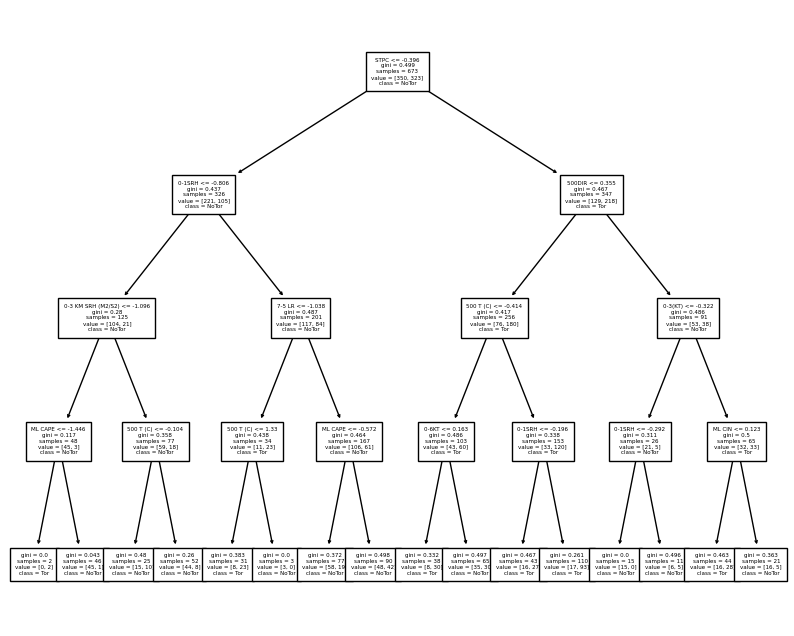

In [75]:
fig, ax = plt.subplots(figsize=(10,8))

plot_tree(model_tree['tree'], feature_names=X_train.columns,  
                   class_names=['NoTor', 'Tor'],
                   ax=ax, fontsize=4)

plt.savefig('decision_tree.png', dpi=300)

In [76]:
y_predict_svc = model.predict(X_test)
y_predict_tree = model_tree.predict(X_test)

## Step 8: Evaluate Models with Confusion Matrix

A **confusion matrix** shows how often our model makes correct vs. incorrect predictions:

```
                 Predicted
                Negative  Positive
Actual Negative   TN (✓)    FP (✗)      [False Positives = Type I Error]
       Positive   FN (✗)    TP (✓)      [False Negatives = Type II Error]
```

### Classification Metrics Derived from Confusion Matrix

- **True Positive (TP)**: Correctly predicted tornado (model said "yes", actually yes)
- **True Negative (TN)**: Correctly predicted no tornado (model said "no", actually no)
- **False Positive (FP)**: Incorrectly predicted tornado (model said "yes", actually no)—Type I error
- **False Negative (FN)**: Incorrectly predicted no tornado (model said "no", actually yes)—Type II error

### Which errors matter?

In tornado prediction:
- **False Negatives are costly**: Failing to warn about a real tornado endangers lives
- **False Positives are less costly**: A false alarm creates inconvenience but doesn't endanger lives

This is why we sometimes prefer models with higher sensitivity (few false negatives) over high accuracy.

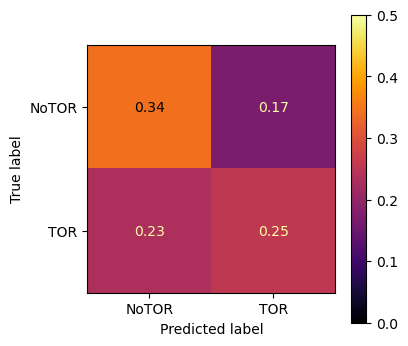

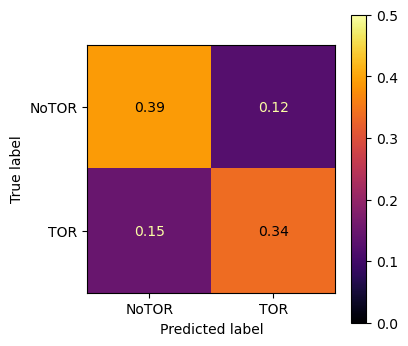

(0.33727810650887574,
 0.1242603550295858,
 0.14792899408284024,
 0.3905325443786982)

In [77]:
def show_confusion_matrix(test, predict, normalize='all', labels=['NoTOR','TOR'],\
                          figsize=(4,4), clim=(0,.5)):

    # Make a confusion matrix for the SVC model
    cm = confusion_matrix(test, predict, normalize=normalize)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, \
                                  display_labels=labels)
    fig, ax = plt.subplots(figsize=figsize)
    disp.plot(cmap='inferno', ax=ax)
    disp.ax_.get_images()[0].set_clim(clim[0], clim[1]) # Sets the limits of the colorbar between 0 and .5
    plt.show()
    
    d, b, c, a = cm.flatten()
    return a, b, c, d
    
show_confusion_matrix(y_test, y_predict_tree)
show_confusion_matrix(y_test, y_predict_svc)

---

# Part 2: Advanced Model Development—Grid Search and Cross-Validation

## The Problem with Manual Hyperparameter Selection

In Part 1, we manually chose hyperparameters (tree depth, SVC C-value) based on intuition. This approach has serious problems:

### Problem 1: Data Leakage
If we evaluate hyperparameters using the test set, we're letting test information influence our choices. Even unconsciously, we'll pick parameters that perform well on tests—meaning we're building to that test set, not to general unseen data. This is **cheating**.

### Problem 2: Trial and Error
Manually trying values is inefficient and incomplete. We might miss the optimal configuration entirely.

## The Solution: Grid Search with Cross-Validation

**Grid Search** systematically tests all combinations of hyperparameter values. For each combination, we use **Cross-Validation** to robustly estimate performance without touching the test set.

### How It Works

1. **Define a parameter grid**: All combinations to test (e.g., max_depth ∈ {2,4,7,12,16} and n_components ∈ {1,...,11})
2. **k-Fold Cross-Validation**: Divide training data into k parts (folds)
3. For each hyperparameter combination:
   - Train k models (leaving one fold out each time)
   - Evaluate on the held-out fold
   - Average the k scores
4. **Select the best**: Use the hyperparameter combination with the highest average score
5. **Final evaluation**: Test on the held-out test set (which we haven't touched until now)

This approach prevents data leakage while systematically finding good hyperparameters.

Let's implement grid search using a new pipeline with StandardScaler, PCA (for dimensionality reduction), and DecisionTreeClassifier:

In [78]:
# Define the parameter grid
model_tree = Pipeline([('scaling', StandardScaler()), 
                       ('pca', PCA()), \
                       ('tree', DecisionTreeClassifier())])

## Step 9: Define the Hyperparameter Search Space

In grid search, we specify all hyperparameter values to test. This creates a "grid" of combinations to explore.

### Hyperparameter 1: Tree Depth

- **Shallow trees** (depth=2): Few splits, simple rules, may underfit
- **Deep trees** (depth=16): Many splits, complex rules, may overfit
- **Optimal depth**: Some middle value that balances these tradeoffs

### Hyperparameter 2: PCA Components

**Principal Component Analysis (PCA)** is dimensionality reduction—converting many features into fewer "principal components" that capture the most variation.

Why use PCA?
- **Reduces noise**: Keeps important signal, removes irrelevant details
- **Prevents overfitting**: Fewer components = simpler model
- **Computational efficiency**: Fewer dimensions = faster training

How it works:
- First component captures the most variance in data
- Second component captures the next-most (orthogonal to first)
- And so on...

By choosing how many components to keep (1-11), we control the information level. Too few loses important signal; too many includes noise.

### The Grid

Our parameter grid combines all possibilities: 5 depth values × 11 component values = 55 configurations to test. Grid search will try all 55!

In [79]:
parameter_grid = [{'tree__max_depth': [2, 4, 7, 12, 16], \
                   'pca__n_components': [1,2,3,4,5,6,7,8,9,10,11]}]

## Step 10: Cross-Validation—Robust Performance Estimation

Cross-validation is a technique to estimate model performance without using the test set. It works by resampling the training data itself.

### k-Fold Cross-Validation

With k=5 folds:

1. **Divide** training data into 5 equal parts
2. **Fold 1**: Train on parts 2-5, validate on part 1
3. **Fold 2**: Train on parts 1,3,4,5, validate on part 2
4. **Fold 3**: Train on parts 1,2,4,5, validate on part 3
5. **Fold 4**: Train on parts 1,2,3,5, validate on part 4
6. **Fold 5**: Train on parts 1,2,3,4, validate on part 5
7. **Average** the 5 validation scores

### Why Cross-Validation?

- **Robust estimate**: Single train-test split is affected by which samples happen to be in each set
- **Better use of data**: All training data gets used for both training and validation
- **Detects overfitting**: If training scores are much higher than validation scores, the model is overfitting

### GridSearchCV in scikit-learn

For each hyperparameter combination, GridSearchCV:
1. Performs k-fold cross-validation
2. Scores each fold
3. Averages the scores

Then it ranks all combinations and tells us which performed best. The winning combination becomes our final model.

### Scoring Metric

We use `scoring='accuracy'`: the fraction of correct predictions. Other metrics include precision, recall, F1, and AUC—each suitable for different use cases. See scikit-learn's documentation for the complete list: https://scikit-learn.org/stable/modules/model_evaluation.html

In [80]:
k=5
classifier = GridSearchCV(estimator=model_tree, param_grid=parameter_grid, \
                          cv=k, scoring='accuracy')

## Step 11: Execute Grid Search

Calling `.fit()` on GridSearchCV triggers the complete grid search process:

- For each of the 55 hyperparameter combinations (5 depths × 11 components)
- Perform 5-fold cross-validation
- Fit 5 models per combination = 275 total model fits
- Score each and track performance

This is computationally intensive but completely automatic. The result: we know which hyperparameter combination performs best, with no data leakage to the test set.

In [81]:
classifier.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaling', StandardScaler()),
                                       ('pca', PCA()),
                                       ('tree', DecisionTreeClassifier())]),
             param_grid=[{'pca__n_components': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                                                11],
                          'tree__max_depth': [2, 4, 7, 12, 16]}],
             scoring='accuracy')

## Step 12: Examine Best Hyperparameters

GridSearchCV stores the winning configuration in `best_params_` and the best model in `best_estimator_`. Here we print them to see which hyperparameter values were optimal for our problem.

In [82]:
print(classifier.best_estimator_)
print(classifier.best_params_)

Pipeline(steps=[('scaling', StandardScaler()), ('pca', PCA(n_components=5)),
                ('tree', DecisionTreeClassifier(max_depth=2))])
{'pca__n_components': 5, 'tree__max_depth': 2}


## Step 13: Final Evaluation on Test Set

Now comes the crucial moment: evaluating our optimized model on the test set, which it has never seen. This gives us an honest estimate of how the model will perform on truly new, unseen data in the real world.

Because we've followed proper methodology (separate test set, cross-validation for hyperparameter selection), this test performance should be a reliable estimate of real-world performance.

In [83]:
y_predict = classifier.predict(X_test)

## Step 14: Confusion Matrix Analysis

Finally, we visualize the confusion matrix on the test set. This reveals:
- How many tornado cases we correctly identified (True Positives)
- How many we missed (False Negatives)—dangerous!
- How many non-tornado cases we correctly rejected (True Negatives)
- How many we falsely alarmed (False Positives)—inconvenient but safer

The unnormalized version shows counts; the normalized version shows percentages.

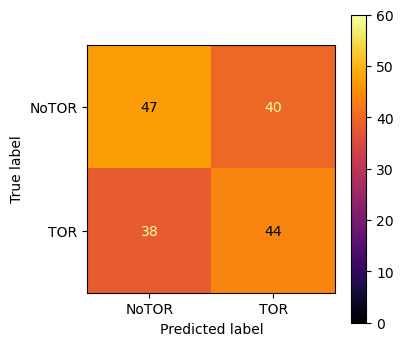

In [84]:
a, b, c, d = show_confusion_matrix(y_test, y_predict, normalize=None, clim=(0,60))

In [85]:
a, b, c, d

(44, 40, 38, 47)

---

# Part 3: Ensemble Methods—Combining Models for Better Predictions

## The Power of Ensembles

In Parts 1 and 2, we built single models (one decision tree, one SVC). While effective, a better approach is building **ensemble models**—multiple weak learners combined to create a strong predictor.

### The Wisdom of Crowds

The ensemble principle works like this: imagine asking 100 meteorologists to independently predict if a supercell will produce a tornado, then taking a majority vote. The combined prediction is likely more reliable than any individual expert's prediction.

Machine learning ensembles work the same way. Different models learn different patterns; combining them leverages this diversity.

### Random Forest

**Random Forest** is an ensemble of decision trees built using randomization:

1. **Bootstrap sampling**: Create multiple training sets by randomly sampling with replacement from the original data
2. **Train trees**: For each bootstrap sample, train a full decision tree
3. **Random feature selection**: At each split, consider only a random subset of features
4. **Combine predictions**: For classification, use majority voting across all trees

### Why Random Forest Works

- **Reduces overfitting**: Individual trees may overfit, but averaging reduces this
- **Handles complexity**: Better captures non-linear relationships than single trees
- **Feature importance**: Can identify which features matter most
- **Robust**: Less sensitive to outliers and noise

Let's apply grid search to optimize a Random Forest model, similar to Part 2:

In [140]:
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid
model_randomforest = Pipeline([('scaling', StandardScaler()), 
                               ('pca', PCA()), \
                               ('rf', RandomForestClassifier())])

parameter_grid = [{'rf__max_depth': [2, 4, 7], \
                   'rf__n_estimators': [100],\
                   'pca__n_components': [4,5,6,7]}]

k=10
classifier = GridSearchCV(estimator=model_randomforest, param_grid=parameter_grid, \
                          cv=k, scoring='accuracy')

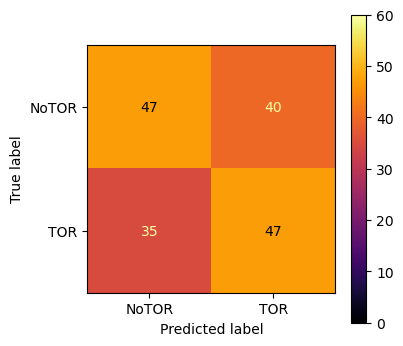

In [141]:
classifier.fit(X_train, y_train.to_numpy().squeeze())
y_predict = classifier.predict(X_test)
a, b, c, d = show_confusion_matrix(y_test, y_predict, normalize=None, clim=(0,60))

In [142]:
y_predict_prob = classifier.predict_proba(X_test)

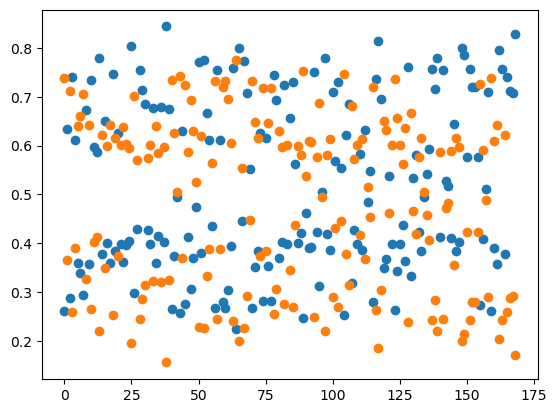

In [143]:
plt.plot(y_predict_prob, 'o')


In [144]:
print(classifier.best_estimator_)
print(classifier.best_params_)

Pipeline(steps=[('scaling', StandardScaler()), ('pca', PCA(n_components=4)),
                ('rf', RandomForestClassifier(max_depth=4, n_estimators=1000))])
{'pca__n_components': 4, 'rf__max_depth': 4, 'rf__n_estimators': 1000}


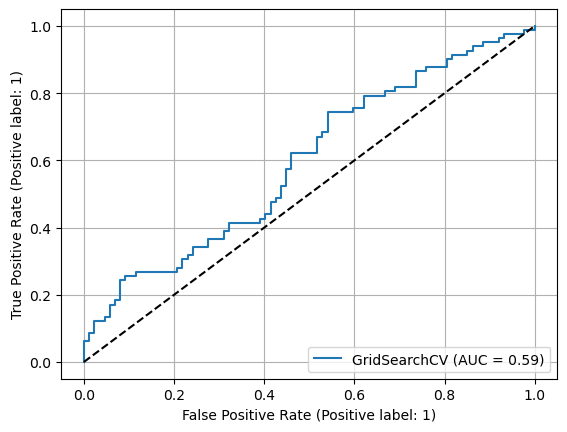

In [145]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(classifier, X_test, y_test, pos_label=1)
plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
plt.grid()

## Summary: Key Takeaways on Building Classification Models

### The Machine Learning Workflow

The complete process we've followed:

1. **Load & Explore**: Understand your data thoroughly
2. **Prepare**: Format features and target appropriately
3. **Split**: Separate training and test sets (80/20 or similar)
4. **Preprocess**: Scale, normalize, or reduce dimensions
5. **Select Model(s)**: Choose appropriate algorithms
6. **Optimize Hyperparameters**: Use grid search + cross-validation
7. **Evaluate**: Test on held-out data
8. **Interpret**: Understand why the model makes predictions

### Critical Principles

**Data Leakage Prevention**: Never let information from the test set influence model development. This includes:
- Don't look at test set performance to guide hyperparameter choices
- Always fit preprocessing (scaling, PCA) only on training data
- Use cross-validation on training data for hyperparameter selection

**Train vs. Validation vs. Test**:
- **Training set**: Used to fit the model
- **Validation set** (via cross-validation): Used to compare hyperparameter choices
- **Test set**: Used only once at the very end for honest performance evaluation

**Model Complexity**:
- **Underfitting**: Model is too simple; poor training AND test performance
- **Good fit**: Model generalizes; both training and test performance are good
- **Overfitting**: Model memorizes training data; good training but poor test performance

### Common Pitfalls to Avoid

1. **Using test data during development**: Leads to overoptimistic performance estimates
2. **Ignoring class imbalance**: When classes are unequal, accuracy can be misleading
3. **Using wrong metrics**: Accuracy isn't always the right choice (recall, precision, F1 matter for imbalanced data)
4. **Not cross-validating**: Single train-test splits can be unrepresentative
5. **Ignoring feature importance**: Understand which variables drive predictions
6. **Over-complex models**: Simpler is often better (Occam's Razor applies to ML)

### When to Use Each Algorithm

- **Decision Trees**: When interpretability is crucial; good for real-world decisions
- **SVCs**: When you have moderate-sized datasets; good for high-dimensional data
- **Random Forests**: When accuracy is priority; handles interactions well; produces feature importance
- **Neural Networks**: When you have large datasets and complex patterns; less interpretable

### Next Steps

To improve your models:
1. **Feature engineering**: Create new features that better capture relationships
2. **Ensemble methods**: Combine multiple model types (voting, stacking)
3. **Threshold tuning**: For probabilistic classifiers, adjust decision thresholds based on application needs
4. **Class weights**: Penalize misclassification of minority classes more heavily
5. **Anomaly detection**: First identify and handle outliers in your data

Good luck with your machine learning projects!